In [ ]:
# <eval_forecast.py>
# Parameters
year_chosen = 2014
eval_start = f"{year_chosen}-08-01"
eval_end = f"{year_chosen}-09-30"
dataset_choice = "imerg"
eval_vars = "total_precipitation_6hr"
apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/"
params_path_old = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'

path_new1_file =\
'\
finetuned/graphcast_1_13_orig_2014-06-01_2014-07-30_FORECAST28_dynamic_weighing_india_mask_expt3_good.npz\
'
path_new2_file =\
'\
graphcast_1_13_orig_2014-06-08_2014-07-30_FORECAST28_india_mask_buffer_expt1_6hourly.npz\
'

params_path_new1 = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/'+ path_new1_file

params_path_new2 = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/' + path_new2_file

norms_dir = '/Datastorage/saptarishi.dhanuka_asp25/norms_gc/'
plots_dir = 'plots/evals'
latmin, latmax, lonmin, lonmax = 6, 38, 35, 65
plot_timesteps = 7
output_pred_old_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'
output_pred_finetuned_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'

"""
Complete evaluation of forecast against different datasets with rainfall analysis
"""
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import sys
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import zarr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

import jax
import optax

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot, compute_difference_with_targets_sims, plot_sample_from_ds
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse, generate_sample_era5_dataset, grads_fn, parse_args, process_to_graphcast_format, compute_mse, compute_mse_diffs

sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
import trainer.dataloader
from dist_utils import construct_era5_imerg, construct_era5_imerg_6hourly
from datetime import datetime

In [2]:
imd_forecast24 = '/Datastorage/saptarishi.dhanuka_asp25/imd_tigge_forecast_2023-08-01_2023-09-30.grib/'
hres_forecast24 = '/Datastorage/saptarishi.dhanuka_asp25/hres_tigge_forecast_2023-08-01_2023-09-30.grib/'
plot_precip_values = True
manual_init_date = ts = pd.Timestamp("2018-08-14 00:00:00")

In [3]:

# --- Basic Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

output_csv_path = "./forecast_evaluation_mse.csv"

# Define India bounding box
INDIA_BBOX = {'lat_min': 6, 'lat_max': 37, 'lon_min': 68, 'lon_max': 97}

# --- Data and Model Loading ---
logging.info(f"Loading dataset '{dataset_choice}' from {eval_start} to {eval_end}")
if dataset_choice == "imerg":
    apath = '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/'
    dbase,_ = trainer.dataloader.open_databases(apath,None)
    # dbase = construct_era5_imerg(dbase, year=year_chosen)
    dbase = construct_era5_imerg_6hourly(dbase, year=year_chosen, save=True)
    # Load a slightly larger window to ensure we have the day before the start_date for initialization
    load_start_date = pd.to_datetime(eval_start) - pd.Timedelta(days=1)
    eval_time_ds = dbase.sel(time=slice(load_start_date.strftime('%Y-%m-%d'), eval_end))
    del dbase


2025-08-22 18:04:49,996 - INFO - Loading dataset 'imerg' from 2014-08-01 to 2014-09-30


Found 173 files in /Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/
Concatenating monthly databases
Using existing file at /Datastorage/saptarishi.dhanuka_asp25/imerg_era5_2014.nc


In [4]:
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.7' 
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

In [5]:
eval_time_ds

<xarray.Dataset> Size: 15GB
Dimensions:                  (time: 248, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 2kB 2014-07-31 ... 2014-09...
    number                   int64 8B ...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 65MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 65MB ...
    2m_temperature           (time, latitude, longitude) float32 65MB ...
    geopotential             (time, level, latitude, longitude) float32 2GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 2GB ...
    temperature              (time, level, latitude, longitude) float32 2GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 65MB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 2GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 2GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 2GB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-06T09:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [ ]:

select_time_eval = process_to_graphcast_format(eval_time_ds)
logging.info(f"Full data range loaded: {select_time_eval.time.values[0]} to {select_time_eval.time.values[-1]}")

logging.info("Loading models and normalization stats...")
with open(params_path_old, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)
params = ckpt.params

with open(params_path_new1, "rb") as f:
    new_params1 = checkpoint.load(f, graphcast.CheckPoint).params
with open(params_path_new2, "rb") as f:
    new_params2 = checkpoint.load(f, graphcast.CheckPoint).params

with open('/Datastorage/saptarishi.dhanuka_asp25/norms_gc/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/norms_gc/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/norms_gc/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()

# --- JAX Function Setup ---
logging.info("Setting up JAX functions...")
state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
setup_jax_functions.update_configs({
    'params': ckpt.params, 'state': state, 'model_config': ckpt.model_config, 'task_config': task_config,
    'mean_by_level': mean_by_level, 'stddev_by_level': stddev_by_level, 'diffs_stddev_by_level': diffs_stddev_by_level
})
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
    setup_jax_functions.run_forward.apply))))
jax.config.update("jax_enable_x64", True)

def run_model(params, state, inputs, targets_template, forcings):
    return run_forward_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=inputs,
        targets_template=targets_template,
        forcings=forcings,
        params=params,
        state=state
    )

# --- Helper Functions for Rainfall Analysis ---
def subset_to_india(data_array):
    """Subset xarray data to India bounding box, with automatic lat/lon ordering check."""
    # Determine if latitude is ascending or descending
    lat_ascending = data_array.lat[0] < data_array.lat[-1]
    lon_ascending = data_array.lon[0] < data_array.lon[-1]

    # Create slices based on ordering
    lat_slice = slice(INDIA_BBOX['lat_min'], INDIA_BBOX['lat_max']) if lat_ascending \
                else slice(INDIA_BBOX['lat_max'], INDIA_BBOX['lat_min'])
    
    lon_slice = slice(INDIA_BBOX['lon_min'], INDIA_BBOX['lon_max']) if lon_ascending \
                else slice(INDIA_BBOX['lon_max'], INDIA_BBOX['lon_min'])

    return data_array.sel(lat=lat_slice, lon=lon_slice)


def calculate_total_rainfall(data_array, subset_region=True):
    """Calculate total rainfall sum over spatial dimensions"""
    if subset_region:
        data_array = subset_to_india(data_array)
    return data_array.sum(dim=['lat', 'lon'])

def plot_spatial_map(data, title, save_path, vmin=None, vmax=None, cmap='Blues'):
    """Plot spatial map with India boundaries"""
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Set extent to India
    ax.set_extent([INDIA_BBOX['lon_min'], INDIA_BBOX['lon_max'], 
                   INDIA_BBOX['lat_min'], INDIA_BBOX['lat_max']], ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    
    # Plot data
    im = ax.contourf(data.lon, data.lat, data, levels=20, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=vmin, vmax=vmax, extend='max')
    
    plt.colorbar(im, ax=ax, shrink=0.8, label='mm/6hr')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def create_rainfall_plots(ground_truth, predictions_dict, init_date, forecast_step, output_dir):
    """Create spatial plots for ground truth, predictions, and differences"""
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Subset all data to India
    gt_india = subset_to_india(ground_truth)
    
    # Determine common color scale
    all_data = [gt_india]
    pred_india = {}
    for name, pred in predictions_dict.items():
        if eval_vars in pred:
            pred_data = subset_to_india(pred[eval_vars])
        else:
            pred_data = subset_to_india(pred)
        pred_india[name] = pred_data
        all_data.append(pred_data)
    
    # Calculate common vmin, vmax
    vmin = 0
    vmax = float(np.nanmax([np.nanmax(d.values) for d in all_data]))
    
    # Plot ground truth
    plot_spatial_map(gt_india, f'Ground Truth - {init_date.strftime("%Y-%m-%d")} - Step {forecast_step}',
                     f'{output_dir}/ground_truth_{init_date.strftime("%Y%m%d")}_step_{forecast_step:02d}.png',
                     vmin=vmin, vmax=vmax)
    
    # Plot predictions
    for model_name, pred_data in pred_india.items():
        plot_spatial_map(pred_data, f'{model_name} - {init_date.strftime("%Y-%m-%d")} - Step {forecast_step}',
                         f'{output_dir}/{model_name.lower()}_{init_date.strftime("%Y%m%d")}_step_{forecast_step:02d}.png',
                         vmin=vmin, vmax=vmax)
    
    # Plot differences between predictions
    model_names = list(pred_india.keys())
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            diff = pred_india[model_names[i]] - pred_india[model_names[j]]
            diff_max = float(np.nanmax(np.abs(diff.values)))
            plot_spatial_map(diff, f'Difference: {model_names[i]} - {model_names[j]} - Step {forecast_step}',
                           f'{output_dir}/diff_{model_names[i].lower()}_{model_names[j].lower()}_step_{forecast_step:02d}.png',
                           vmin=-diff_max, vmax=diff_max, cmap='RdBu_r')

# --- HRES Data Handling ---
import glob
def extract_hres_date(path):
    parts = path.split('_')
    year = 2014  # fixed, or extract if you want dynamic
    month = int(parts[5])
    day = int(parts[6])
    return datetime(year, month, day)

logging.info("Mapping HRES forecast files...")
hres_file_list = glob.glob("/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2024/*.grib")
hres_files_map = {extract_hres_date(p): p for p in hres_file_list}

# =============================================================================
# === SYSTEMATIC EVALUATION WITH RAINFALL ANALYSIS ===========================
# =============================================================================
all_results = []
all_rainfall_totals = []  # New: store total rainfall data
initialization_dates = pd.to_datetime(pd.date_range(start=eval_start, end=eval_end, freq='D'))

# Max forecast length is 7 days (28 steps of 6 hours)
MAX_FORECAST_STEPS = 28
target_lead_times_str = f"{(MAX_FORECAST_STEPS) * 6}h"
target_lead_times_slice = slice("6h", target_lead_times_str)
forecast_horizons_def = {1: 4, 3: 12, 7: 28}  # In 6-hourly steps

logging.info(f"Starting evaluation for {len(initialization_dates)} initialization dates.")

# Create output directories for plots
plots_dir = "./evaluation_results/spatial_plots"
os.makedirs(plots_dir, exist_ok=True)


2025-08-22 18:05:17,044 - INFO - Full data range loaded: 0 nanoseconds to 5335200000000000 nanoseconds
2025-08-22 18:05:17,045 - INFO - Loading models and normalization stats...
2025-08-22 18:05:17,520 - INFO - Setting up JAX functions...
2025-08-22 18:05:17,522 - INFO - Mapping HRES forecast files...
2025-08-22 18:05:17,524 - INFO - Starting evaluation for 61 initialization dates.


In [7]:
initialization_dates

DatetimeIndex(['2014-08-01', '2014-08-02', '2014-08-03', '2014-08-04',
               '2014-08-05', '2014-08-06', '2014-08-07', '2014-08-08',
               '2014-08-09', '2014-08-10', '2014-08-11', '2014-08-12',
               '2014-08-13', '2014-08-14', '2014-08-15', '2014-08-16',
               '2014-08-17', '2014-08-18', '2014-08-19', '2014-08-20',
               '2014-08-21', '2014-08-22', '2014-08-23', '2014-08-24',
               '2014-08-25', '2014-08-26', '2014-08-27', '2014-08-28',
               '2014-08-29', '2014-08-30', '2014-08-31', '2014-09-01',
               '2014-09-02', '2014-09-03', '2014-09-04', '2014-09-05',
               '2014-09-06', '2014-09-07', '2014-09-08', '2014-09-09',
               '2014-09-10', '2014-09-11', '2014-09-12', '2014-09-13',
               '2014-09-14', '2014-09-15', '2014-09-16', '2014-09-17',
               '2014-09-18', '2014-09-19', '2014-09-20', '2014-09-21',
               '2014-09-22', '2014-09-23', '2014-09-24', '2014-09-25',
      

In [8]:
init_date = initialization_dates[4]
# init_date = manual_init_date
init_date

Timestamp('2014-08-05 00:00:00')

In [9]:
# init_idx = 0

# 1. Load data for this initialization
try:
    # end_slice is a week after the starting. we need the start_slice to be behind by 6 hours cause graphcast needs 2 timesteps initially
    start_slice = init_date - pd.Timedelta(hours=6)
    end_slice = init_date + pd.Timedelta(days=7)
    start_slice -= select_time_eval.datetime.values[0][0]
    end_slice -= select_time_eval.datetime.values[0][0]

    from dask.diagnostics import ProgressBar
    with ProgressBar():
        eval_sim_data = select_time_eval.sel(time=slice(start_slice, end_slice)).compute()

    if eval_sim_data.sizes["time"] < 2:
        logging.warning(f"Not enough data for initialization {init_date}. Found {eval_sim_data.sizes['time']} steps. Skipping.")
        
except Exception as e:
    logging.warning(f"Could not load data for {init_date}: {e}. Skipping.")
    

# 2. Prepare inputs, targets, and forcings for a 7-day rollout
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    eval_sim_data, target_lead_times=target_lead_times_slice, **dataclasses.asdict(task_config))

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

if (eval_inputs.dims.mapping['time'] != 2):
    print("\nError in extracting inputs targets and forcings\n")
    

if eval_targets.sizes['time'] < MAX_FORECAST_STEPS:
    logging.warning(f"Not enough target data for a 7-day forecast from {init_date}. Have {eval_targets.sizes['time']} steps. Skipping.")
    

targets_template = eval_targets * np.nan
ground_truth_var = eval_targets[eval_vars]

# 3. Run all Graphcast models
logging.debug(f"Running Graphcast models for {init_date}")
print("Base run")
predictions_base = run_model(params, state, eval_inputs, targets_template, eval_forcings)
print("Finetuned 1")
predictions_ft1 = run_model(new_params1, state, eval_inputs, targets_template, eval_forcings)
print("Finetuned 2")
predictions_ft2 = run_model(new_params2, state, eval_inputs, targets_template, eval_forcings)

models_to_eval = {
    'Graphcast_Base' + str(year_chosen): predictions_base,
    'Graphcast_Finetuned1' + path_new1_file: predictions_ft1,
    'Graphcast_Finetuned2' + path_new2_file: predictions_ft2,
}

# 4. Load, regrid, and align HRES forecast
hres_predictions = None
hres_file_path = hres_files_map.get(init_date.to_pydatetime().replace(hour=0, minute=0, second=0, microsecond=0))
if hres_file_path:
    try:
        logging.debug(f"Processing HRES file: {hres_file_path}")
        hres_ds = xr.open_dataset(hres_file_path, engine='cfgrib')
        hres_regridded = regrid_hres_fine_to_coarse(hres_ds, variable='tp', coarse_resolution=1.0)
        hres_predictions = hres_regridded.drop_vars({'time'}).rename({'step': 'time'}).isel(time=slice(1,None)).assign_coords(time=eval_targets.time)
        models_to_eval['HRES'] = hres_predictions
    except Exception as e:
        logging.warning(f"Failed to process HRES file {hres_file_path}: {e}")
else:
    logging.warning(f"No HRES file found for init date {init_date}")

# 5. Calculate total rainfall for ground truth
ground_truth_rainfall_totals = calculate_total_rainfall(ground_truth_var).values
print(models_to_eval.keys())

2025-08-22 18:05:18,222 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-08-22 18:05:18,224 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Base run
Finetuned 1
Finetuned 2


/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built
dict_keys(['Graphcast_Base2014', 'Graphcast_Finetuned1finetuned/graphcast_1_13_orig_2014-06-01_2014-07-30_FORECAST28_dynamic_weighing_india_mask_expt3_good.npz', 'Graphcast_Finetuned2graphcast_1_13_orig_2014-06-08_2014-07-30_FORECAST28_india_mask_buffer_expt1_6hourly.npz', 'HRES'])


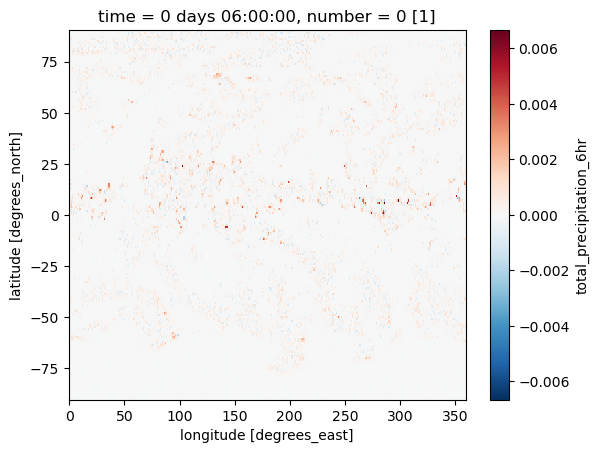

In [10]:
(predictions_base['total_precipitation_6hr'] - predictions_ft1['total_precipitation_6hr']).isel(time=0).plot()

In [11]:
import xarray as xr
import matplotlib.pyplot as plt

def accum_time_and_plot_hres(
    *data_objs,
    var_name: str = None,
    indiaplot: bool = True,
    lat_range: tuple[float,float] = (6, 38),
    lon_range: tuple[float,float] = (68, 98),
    max_datasets: int = 6,
):
    """
    Sum over time and overlay up to `max_datasets` xarray objects on one plot.

    Parameters
    ----------
    *data_objs : xarray.DataArray or xarray.Dataset
        One or more xarray objects to plot.  If passing a Dataset, you must
        supply `var_name` so we know which variable to use.
    var_name : str, optional
        Name of the variable in each Dataset to plot.  Not needed if you pass
        DataArray(s).
    indiaplot : bool
        If True, first subset each result to the given India lat/lon box.
    lat_range : (min_lat, max_lat)
        Latitude bounds in degrees north.
    lon_range : (min_lon, max_lon)
        Longitude bounds in degrees east.
    max_datasets : int
        Maximum number of objects you may pass in.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    if not data_objs:
        raise ValueError("Must pass at least one DataArray or Dataset.")
    if len(data_objs) > max_datasets:
        raise ValueError(f"Cannot plot more than {max_datasets} datasets at once.")

    fig, ax = plt.subplots()

    for i, ds in enumerate(data_objs, start=1):
        # 1) Extract DataArray:
        if isinstance(ds, xr.Dataset):
            if var_name is None:
                raise ValueError("var_name is required when passing a Dataset.")
            da = ds[var_name]
        else:
            da = ds

        # 2) Find the time-like dimension:
        if "time" in da.dims:
            time_dim = "time"
        elif "valid_time" in da.dims:
            time_dim = "valid_time"
        else:
            # fallback: pick first datetime64 dimension
            time_dim = next(
                d for d in da.dims
                if da[d].dtype.kind == "M"
            )

        # 3) Sum over time
        da_sum = da.sum(dim=time_dim)

        # 4) Detect lat/lon coord names
        lat_name = "latitude" if "latitude" in da_sum.coords else "lat"
        lon_name = "longitude" if "longitude" in da_sum.coords else "lon"

        # 5) Check if lat is ascending or descending
        ascending = da_sum[lat_name].values[0] < da_sum[lat_name].values[-1]

        # 6) Subset to India box if requested
        if indiaplot:
            min_lat, max_lat = lat_range
            min_lon, max_lon = lon_range

            if ascending:
                da_sum = da_sum.sel(
                    **{lat_name: slice(min_lat, max_lat),
                       lon_name: slice(min_lon, max_lon)}
                )
            else:
                da_sum = da_sum.sel(
                    **{lat_name: slice(max_lat, min_lat),
                       lon_name: slice(min_lon, max_lon)}
                )

        # 7) Plot onto the same axes
        label = getattr(da, "name", None) or f"ds{i}"
        da_sum.plot(ax=ax, label=label)

    ax.legend()
    ax.set_title("Accumulated sum over time")
    return fig, ax


In [12]:
import jax
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
import argparse
import setup_jax_functions
from tqdm import tqdm


import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from shapely.geometry import mapping


def mask_dbase_india_buffer(dbase, buffer=True, buffer_deg=2.0, crs="EPSG:4326", lat_thresh=23.5):

    if "latitude" in dbase.coords:
        dbase = dbase.rename({"latitude": "lat", "longitude": "lon"})

    # Load world boundaries from Natural Earth (built-in to geopandas)
    world = gpd.read_file("/Datastorage/saptarishi.dhanuka_asp25/ne_110m_admin_0_countries.shp")
    india = world[world.SOVEREIGNT == 'India']
    india_gdf = india.geometry

    """
    return a GeoSeries with the original land unioned with a 1° coastal buffer
    everywhere south of lat_thresh.
    """
    # 1. Ensure it's in lat/lon
    india_gdf = india_gdf.to_crs(crs)
    
    # 2. Merge all parts into one Polygon/MultiPolygon
    land = unary_union(india_gdf.geometry)
    
    # 3. Build a global mask for lat < lat_thresh
    lat_mask = box(-180, -90, 180, lat_thresh)
    
    # 4. Buffer the land by buffer_deg (in degrees)
    land_buffered = land.buffer(buffer_deg)
    
    # 5. Restrict the buffer to lat < lat_thresh, then subtract land to get just the new strip
    coastal_extension = (land_buffered
                         .intersection(lat_mask)
                         .difference(land))
    
    # 6. Union land + extension
    extended = land.union(coastal_extension)

    extended_series = gpd.GeoSeries([extended], crs=crs)



    mask = geometry_mask(
    [mapping(extended_series.iloc[0])],     # List of geometries
    out_shape=(len(dbase.lat), len(dbase.lon)),
    transform=dbase.rio.transform(),
    invert=True,                           # Areas *inside* geometry == True
    all_touched=False
)

    # Convert mask to xarray DataArray (True inside India, False outside)
    mask_xr = xr.DataArray(mask, coords={"lat": dbase.lat, "lon": dbase.lon}, dims=("lat", "lon"))

    # Apply mask using xarray.where: keep data inside India, zero out rest
    dbase_masked = xr.where(mask_xr, dbase, 0)  # or use `np.nan` instead of 0 if you prefer
    dbase_masked = dbase_masked.assign_coords(lon=((dbase_masked.lon + 360) % 360))
    dbase_masked = dbase_masked.sortby("lon")


    attr_label = dbase.attrs.get("plot_label", None)
    if attr_label is not None:
        dbase_masked.attrs["plot_label"] = attr_label
    return dbase_masked


def mask_dbase_regions(dbase, region_name='West_Central'):
    if 'lon' in dbase.coords:
        dbase = dbase.rename({'lon': 'longitude', 'lat': 'latitude'})
    indiashp_path_regions = "/Datastorage/saptarishi.dhanuka_asp25/shapefile_data/india_homog"

    shapefile_path = indiashp_path_regions
    regions = ['Central_Northeast', 'Hilly_Regions', 'Northeast', 'Northwest', 'South_Peninsular', 'West_Central']
    region_shp = gpd.read_file(shapefile_path, layer=region_name).to_crs(epsg=4326)

    if (dbase.longitude > 180).any():
        dbase = dbase.assign_coords(longitude=(((dbase.longitude + 180) % 360) - 180))
        dbase = dbase.sortby("longitude")

        
    dbase = dbase.rio.write_crs("EPSG:4326", inplace=True)

    mask_region = geometry_mask(
        [mapping(region_shp['geometry'].iloc[0])],     # List of geometries
        out_shape=(len(dbase.latitude), len(dbase.longitude)),
        transform=dbase.rio.transform(),
        invert=True,                           # Areas *inside* geometry == True
        all_touched=False
    )

    mask_xr = xr.DataArray(mask_region, coords={"latitude": dbase.latitude, "longitude": dbase.longitude}, dims=("latitude", "longitude"))

    dbase_masked = xr.where(mask_xr, dbase, 0)
    dbase_masked = dbase_masked.assign_coords(longitude=((dbase_masked.longitude + 360) % 360))
    dbase_masked = dbase_masked.sortby("longitude")

    attr_label = dbase.attrs.get("plot_label", None)
    if attr_label is not None:
        dbase_masked.attrs["plot_label"] = attr_label

    return dbase_masked

In [13]:
import math
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def accum_time_and_plot_ds_perc(
    *data_objs,
    var_name=None,
    indiaplot: bool = True,
    lat_range: tuple[float, float] = (6, 38),
    lon_range: tuple[float, float] = (68, 98),
    max_datasets: int = 6,
    cmap: str = "viridis",
    isdiff: bool = False,
    india_shape: bool = False,
    region_shape: str = None,
    # ---- new knobs for % improvement ----
    compute_percent_improvement: bool = True,
    baseline_index: int = -1,
    improvement_clip: tuple[float, float] = (-100.0, 100.0),
    baseline_eps: float = 1e-12,
):
    """
    Sum over time and plot each xarray object on its own map,
    using `plot_label` attr (if present) for the title.

    If `isdiff=True` and `compute_percent_improvement=True` and at least 2 inputs:
        - Also returns a second figure with % improvement maps for each non-baseline input:
          100 * (baseline - model) / baseline
        - Positive means the model improved (lower error) vs baseline.

    Returns:
        fig_main, axs_main, fig_improve, axs_improve
        (the last two are None if no improvement figure was made)
    """
    n = len(data_objs)
    if n == 0:
        raise ValueError("Must pass at least one DataArray or Dataset.")
    if n > max_datasets:
        raise ValueError(f"Can only plot up to {max_datasets} objects; you passed {n}.")

    # Build per-input var_name list
    if isinstance(var_name, (list, tuple)):
        if len(var_name) != n:
            raise ValueError("`var_name` list must match number of inputs.")
        var_names = list(var_name)
    else:
        var_names = [var_name] * n

    processed = []
    labels = []
    units = None
    gmin, gmax = np.inf, -np.inf

    for ds, vname in zip(data_objs, var_names):
        # Optional masks (commented if you don't have these)
        # if india_shape:
        #     ds = mask_dbase_india_buffer(ds)
        # if region_shape:
        #     ds = mask_dbase_regions(ds, region_name='West_Central')

        # 1) extract DataArray
        if isinstance(ds, xr.Dataset):
            if vname is None:
                raise ValueError("You must supply `var_name` for each Dataset.")
            da = ds[vname]
            label = ds.attrs.get("plot_label", None) or vname or f"ds{len(processed)+1}"
        else:
            da = ds  # assume DataArray
            label = getattr(da, "name", None) or f"da{len(processed)+1}"

        # 2) detect time dim
        if "time" in da.dims:
            tdim = "time"
        elif "valid_time" in da.dims:
            tdim = "valid_time"
        else:
            tdim = next(d for d in da.dims if da[d].dtype.kind == "M")

        # 3) sum over time
        da_sum = da.sum(dim=tdim)

        # 4) subset to India box if requested
        latn = "latitude" if "latitude" in da_sum.coords else "lat"
        lonn = "longitude" if "longitude" in da_sum.coords else "lon"
        if indiaplot:
            mn_lat, mx_lat = lat_range
            mn_lon, mx_lon = lon_range
            asc_lat = da_sum[latn].values[0] < da_sum[latn].values[-1]
            lat_slice = slice(mn_lat, mx_lat) if asc_lat else slice(mx_lat, mn_lat)
            da_sum = da_sum.sel(**{latn: lat_slice, lonn: slice(mn_lon, mx_lon)})

        # track units from the first one (if any)
        if units is None:
            units = getattr(da_sum, "units", None)

        # 5) update global vmin/vmax
        arr = da_sum.values
        gmin = min(gmin, float(np.nanmin(arr)))
        gmax = max(gmax, float(np.nanmax(arr)))

        da_sum.name = label
        processed.append(da_sum)
        labels.append(label)

    # --- MAIN FIG: determine shared color scale ---
    if isdiff:
        abs_max = max(abs(gmin), abs(gmax))
        cmin, cmax = -abs_max, abs_max
        cmap_to_use = "bwr"
    else:
        cmin, cmax = gmin, gmax
        cmap_to_use = cmap

    # --- MAIN FIG: grid ---
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
    axs = np.atleast_1d(axs).flatten()

    # plot each
    last_im = None
    for i, da_sum in enumerate(processed):
        ax = axs[i]
        im = da_sum.plot(ax=ax, vmin=cmin, vmax=cmax, cmap=cmap_to_use, add_colorbar=False)
        ax.set_title(da_sum.name)
        last_im = im

    # colorbar
    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axs[:n], orientation="vertical", label=units)

    # hide unused axes
    for ax in axs[n:]:
        ax.set_visible(False)

    # --- OPTIONAL: % IMPROVEMENT FIG ---
    fig_imp, axs_imp = None, None
    can_do_improvement = (isdiff and compute_percent_improvement and n >= 2)
    if can_do_improvement:
        # Normalize baseline index and fetch
        bidx = baseline_index % n
        base = processed[bidx]
        base_label = labels[bidx]

        # Compute improvement for each non-baseline vs baseline
        improvs = []
        imp_labels = []
        # avoid division by ~0
        base_safe = xr.where(np.abs(base) < baseline_eps, np.nan, base)

        for i, (da_sum, lab) in enumerate(zip(processed, labels)):
            if i == bidx:
                continue
            # % improvement: positive => better (lower error than baseline)
            imp = 100.0 * (base - da_sum) / base_safe
            imp.name = f"% Improvement vs {base_label}\n({lab})"
            improvs.append(imp)
            imp_labels.append(imp.name)

        # Set diverging color scale centered at 0 (clip to user range)
        imin, imax = improvement_clip
        # grid for improvement maps
        m = len(improvs)
        ncols_imp = min(m, 3)
        nrows_imp = math.ceil(m / ncols_imp)
        fig_imp, axs_imp = plt.subplots(nrows_imp, ncols_imp, figsize=(5 * ncols_imp, 4 * nrows_imp), constrained_layout=True)
        axs_imp = np.atleast_1d(axs_imp).flatten()

        last_im2 = None
        for i, imp in enumerate(improvs):
            ax = axs_imp[i]
            im2 = imp.plot(ax=ax, vmin=imin, vmax=imax, cmap="RdYlGn", add_colorbar=False)
            ax.set_title(imp.name)
            last_im2 = im2

        if last_im2 is not None:
            cbar2 = fig_imp.colorbar(
                last_im2, ax=axs_imp[:m], orientation="vertical",
                label="% improvement (positive = better)"
            )
        for ax in axs_imp[m:]:
            ax.set_visible(False)

    return fig, axs, fig_imp, axs_imp


In [14]:
eval_targets = eval_targets.assign_attrs(plot_label="Eval Targets", init_date=init_date)
predictions_base = predictions_base.assign_attrs(plot_label="Base", init_date=init_date)
predictions_ft1 = predictions_ft1.assign_attrs(plot_label="Finetuned 1", init_date=init_date)
predictions_ft2 = predictions_ft2.assign_attrs(plot_label="Finetuned 2", init_date=init_date)

In [15]:
# eval_targets.to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/main_eval_7_days_targets_010824.nc')
# predictions_ft1.to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/main_eval_7_days_fine_010824.nc')
# predictions_base.to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/main_eval_7_days_base_010824.nc')

In [16]:
print(eval_targets)

<xarray.Dataset> Size: 606MB
Dimensions:                  (batch: 1, time: 28, lat: 181, lon: 360, level: 13)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float32 7MB 208.8 ... 273.7
    mean_sea_level_pressure  (batch, time, lat, lon) float32 7MB 9.998e+04 .....
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB -0.2737 ... ...
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB 0.5327 ... -...
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB 0.0 0.0 ... 0.0
    temperature              (batch, time, level, lat, l

In [17]:
# pip install xarray numpy
import numpy as np
import xarray as xr

def compute_acc_precip_6h(
    predictions_ds: xr.Dataset,
    targets_ds: xr.Dataset,
    clim_6h_da: xr.DataArray,
    *,
    start_time: str = "2024-08-01T00:00",  # predictions/targets start 00Z Aug 1, 2024
    pred_var: str = "total_precipitation_6hr",
    targ_var: str = "total_precipitation_6hr",
    use_coslat_weights: bool = True,
):
    """
    Compute area-weighted spatial ACC(time) for 6-hourly precip using 6-hourly climatology.

    predictions_ds: Dataset with pred_var (time, batch, lat, lon)
    targets_ds:     Dataset with targ_var (batch, time, lat, lon)
    clim_6h_da:     6-hourly climatology with dims (hour, dayofyear, latitude, longitude)
                    and hours in {0, 6, 12, 18}.
    """

    # --- 0) Tidy inputs & align ---
    pred6 = predictions_ds[pred_var].squeeze("batch", drop=True)  # (time, lat, lon)
    targ6 = targets_ds[targ_var].squeeze("batch", drop=True)      # (time, lat, lon)
    pred6, targ6 = xr.align(pred6, targ6, join="inner")

    # --- 1) Absolute valid times from lead-times + known start ---
    t0 = np.datetime64(start_time)
    valid_time = xr.DataArray(t0 + pred6["time"].values, coords={"time": pred6["time"]}, dims=("time",))

    # --- 2) Put climatology on prediction grid (rename & interp) ---
    clim = clim_6h_da.rename({"latitude": "lat", "longitude": "lon"})
    clim_on_grid = clim.interp(lat=pred6["lat"], lon=pred6["lon"])  # swap for xESMF if you need conservative

    # --- 3) Match each timestamp to (dayofyear, hour) in the climatology ---
    doy = xr.DataArray(valid_time.dt.dayofyear, coords={"time": pred6["time"]}, dims=("time",))
    hr  = xr.DataArray(valid_time.dt.hour,       coords={"time": pred6["time"]}, dims=("time",))
    # snap to {0,6,12,18} in case of tiny offsets
    hr = (np.floor_divide(hr, 6) * 6) % 24

    clim_t = clim_on_grid.sel(dayofyear=doy, hour=hr)  # (time, lat, lon)

    # --- 4) Anomalies ---
    f_anom = pred6 - clim_t
    o_anom = targ6 - clim_t

    # --- 5) Area-weighted (cos lat) spatial ACC per time ---
    if use_coslat_weights:
        w = np.cos(np.deg2rad(pred6["lat"])).clip(min=0.0)
    else:
        w = xr.ones_like(pred6["lat"])
    w2d = w.broadcast_like(pred6.isel(time=0))

    def wmean(da):
        return (da * w2d).sum(("lat", "lon"), skipna=True) / w2d.sum(("lat", "lon"))

    # remove weighted spatial mean at each time
    f0 = f_anom - xr.apply_ufunc(wmean, f_anom, input_core_dims=[("lat", "lon")], vectorize=True)
    o0 = o_anom - xr.apply_ufunc(wmean, o_anom, input_core_dims=[("lat", "lon")], vectorize=True)

    num = xr.apply_ufunc(wmean, f0 * o0, input_core_dims=[("lat", "lon")], vectorize=True)
    den = np.sqrt(
        xr.apply_ufunc(wmean, f0 * f0, input_core_dims=[("lat", "lon")], vectorize=True)
        * xr.apply_ufunc(wmean, o0 * o0, input_core_dims=[("lat", "lon")], vectorize=True)
    )

    acc = (num / den).rename("ACC_6h")
    acc = acc.assign_coords(valid_time=valid_time).assign_attrs(
        description="Cos(lat)-weighted spatial ACC of 6h precip anomalies (WeatherBench 6h climatology)"
    )
    return acc



In [18]:
import math
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def accum_time_and_plot_ds(
    *data_objs,
    var_name=None,
    indiaplot: bool = True,
    lat_range: tuple[float, float] = (6, 38),
    lon_range: tuple[float, float] = (68, 98),
    max_datasets: int = 6,
    cmap: str = "viridis",
    isdiff: bool = False,
    india_shape: bool = False,
    region_shape: str = None,
    outline: bool = False,
    subplot_titles: list[str] = None,
    xlabel: str = None,
    ylabel: str = None,
    units: str = None
):
    """
    Sum over time and plot each xarray object on its own map,
    with optional Cartopy land/sea outline.
    Allows custom subplot titles and axis labels.
    """
    n = len(data_objs)
    if n == 0:
        raise ValueError("Must pass at least one DataArray or Dataset.")
    if n > max_datasets:
        raise ValueError(f"Can only plot up to {max_datasets} objects; you passed {n}.")

    # Build per-input var_name list
    if isinstance(var_name, (list, tuple)):
        if len(var_name) != n:
            raise ValueError("`var_name` list must match number of inputs.")
        var_names = list(var_name)
    else:
        var_names = [var_name] * n

    # First pass: process each, track global vmin/vmax
    processed = []
    gmin, gmax = np.inf, -np.inf

    for ds, vname in zip(data_objs, var_names):
        if india_shape:
            ds = mask_dbase_india_buffer(ds)
        if region_shape:
            ds = mask_dbase_regions(ds, region_name='West_Central')

        # 1) extract DataArray
        if isinstance(ds, xr.Dataset):
            if vname is None:
                raise ValueError("You must supply `var_name` for each Dataset.")
            da = ds[vname]
        else:
            da = ds

        # 2) detect time dim
        tdim = None
        for dim in da.dims:
            if dim.lower() in ["time", "valid_time"]:
                tdim = dim
                break
        if tdim is None:
            tdim = next(d for d in da.dims if da[d].dtype.kind == "M")

        # 3) sum over time
        da_sum = da.sum(dim=tdim)

        # 4) assign label
        label = ds.attrs.get("plot_label", None) or da.name or vname or f"ds{len(processed)+1}"
        da_sum.name = label

        # 5) subset India region if needed
        latn = "latitude" if "latitude" in da_sum.coords else "lat"
        lonn = "longitude" if "longitude" in da_sum.coords else "lon"
        if indiaplot:
            mn_lat, mx_lat = lat_range
            mn_lon, mx_lon = lon_range
            asc = da_sum[latn].values[0] < da_sum[latn].values[-1]
            if asc:
                da_sum = da_sum.sel(**{latn: slice(mn_lat, mx_lat),
                                        lonn: slice(mn_lon, mx_lon)})
            else:
                da_sum = da_sum.sel(**{latn: slice(mx_lat, mn_lat),
                                        lonn: slice(mn_lon, mx_lon)})

        # 6) update global vmin/vmax
        arr = da_sum.values
        gmin = min(gmin, float(np.nanmin(arr)))
        gmax = max(gmax, float(np.nanmax(arr)))

        processed.append(da_sum)

    # Determine shared color scale
    if isdiff:
        abs_max = max(abs(gmin), abs(gmax))
        cmin, cmax = -abs_max, abs_max
        cmap_to_use = 'bwr'
    else:
        cmin, cmax = gmin, gmax
        cmap_to_use = cmap

    # Create subplot grid
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)
    fig = plt.figure(figsize=(5 * ncols, 4 * nrows), constrained_layout=True)

    # Plot each dataset
    for i, da_sum in enumerate(processed):
        if outline:
            ax = plt.subplot(nrows, ncols, i + 1, projection=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', linewidth=1)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
            if indiaplot:
                ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]])
        else:
            ax = plt.subplot(nrows, ncols, i + 1)

        im = da_sum.plot(
            ax=ax,
            vmin=cmin,
            vmax=cmax,
            cmap=cmap_to_use,
            add_colorbar=False,
            transform=ccrs.PlateCarree() if outline else None
        )

        # Set subplot title
        if subplot_titles and i < len(subplot_titles):
            ax.set_title(subplot_titles[i])
        else:
            ax.set_title(da_sum.name)

        # Set axis labels
        if xlabel:
            ax.set_xlabel(xlabel)
        if ylabel:
            ax.set_ylabel(ylabel)

    # Single shared colorbar
    # cbar = fig.colorbar(im, ax=fig.axes, orientation="vertical",
                        # label=getattr(processed[0], "units", None))

                        # Single shared colorbar
    cbar_label = units or getattr(processed[0], "units", None)
    cbar = fig.colorbar(im, ax=fig.axes, orientation="vertical", label=cbar_label)

    return fig, fig.axes


In [19]:
# manual_init = '2024-09-14'
# opt_targ = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{manual_init} 00:00:00.nc')
# opt_base = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/base_init_{manual_init} 00:00:00.nc')
# opt_fine = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/fine_init_{manual_init} 00:00:00.nc')

In [20]:
# eval_targets = opt_targ
# predictions_base = opt_base
# predictions_ft1 = opt_fine

In [21]:
import math
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def accum_time_and_plot_ds(
    *data_objs,
    var_name=None,
    indiaplot: bool = True,
    lat_range: tuple[float, float] = (6, 38),
    lon_range: tuple[float, float] = (68, 98),
    max_datasets: int = 6,
    cmap: str = "viridis",
    isdiff: bool = False,
    india_shape: bool = False,
    region_shape: str = None,
    outline: bool = False,
    subplot_titles: list[str] = None,
    xlabel: str = None,
    ylabel: str = None,
    units: str = None
):
    """
    Sum over time and plot each xarray object on its own map,
    with optional Cartopy land/sea outline.
    Allows custom subplot titles and axis labels.
    """
    n = len(data_objs)
    if n == 0:
        raise ValueError("Must pass at least one DataArray or Dataset.")
    if n > max_datasets:
        raise ValueError(f"Can only plot up to {max_datasets} objects; you passed {n}.")

    # Build per-input var_name list
    if isinstance(var_name, (list, tuple)):
        if len(var_name) != n:
            raise ValueError("`var_name` list must match number of inputs.")
        var_names = list(var_name)
    else:
        var_names = [var_name] * n

    # First pass: process each, track global vmin/vmax
    processed = []
    gmin, gmax = np.inf, -np.inf

    for ds, vname in zip(data_objs, var_names):
        if india_shape:
            ds = mask_dbase_india_buffer(ds)
        if region_shape:
            ds = mask_dbase_regions(ds, region_name='West_Central')

        # 1) extract DataArray
        if isinstance(ds, xr.Dataset):
            if vname is None:
                raise ValueError("You must supply `var_name` for each Dataset.")
            da = ds[vname]
        else:
            da = ds

        # 2) detect time dim
        tdim = None
        for dim in da.dims:
            if dim.lower() in ["time", "valid_time"]:
                tdim = dim
                break
        if tdim is None:
            tdim = next(d for d in da.dims if da[d].dtype.kind == "M")

        # 3) sum over time
        da_sum = da.sum(dim=tdim)

        # 4) assign label
        label = ds.attrs.get("plot_label", None) or da.name or vname or f"ds{len(processed)+1}"
        da_sum.name = label

        # 5) subset India region if needed
        latn = "latitude" if "latitude" in da_sum.coords else "lat"
        lonn = "longitude" if "longitude" in da_sum.coords else "lon"
        if indiaplot:
            mn_lat, mx_lat = lat_range
            mn_lon, mx_lon = lon_range
            asc = da_sum[latn].values[0] < da_sum[latn].values[-1]
            if asc:
                da_sum = da_sum.sel(**{latn: slice(mn_lat, mx_lat),
                                        lonn: slice(mn_lon, mx_lon)})
            else:
                da_sum = da_sum.sel(**{latn: slice(mx_lat, mn_lat),
                                        lonn: slice(mn_lon, mx_lon)})

        # 6) update global vmin/vmax
        arr = da_sum.values
        gmin = min(gmin, float(np.nanmin(arr)))
        gmax = max(gmax, float(np.nanmax(arr)))

        processed.append(da_sum)

    # Determine shared color scale
    if isdiff:
        abs_max = max(abs(gmin), abs(gmax))
        cmin, cmax = -abs_max, abs_max
        cmap_to_use = 'bwr'
    else:
        cmin, cmax = gmin, gmax
        cmap_to_use = cmap

    # Create subplot grid
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)
    fig = plt.figure(figsize=(5 * ncols, 4 * nrows), constrained_layout=True)

    # Plot each dataset
    for i, da_sum in enumerate(processed):
        if outline:
            ax = plt.subplot(nrows, ncols, i + 1, projection=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', linewidth=1)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
            if indiaplot:
                ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]])
        else:
            ax = plt.subplot(nrows, ncols, i + 1)

        im = da_sum.plot(
            ax=ax,
            vmin=cmin,
            vmax=cmax,
            cmap=cmap_to_use,
            add_colorbar=False,
            transform=ccrs.PlateCarree() if outline else None
        )

        # Set subplot title
        if subplot_titles and i < len(subplot_titles):
            ax.set_title(subplot_titles[i])
        else:
            ax.set_title(da_sum.name)

        # Set axis labels
        if xlabel:
            ax.set_xlabel(xlabel)
        if ylabel:
            ax.set_ylabel(ylabel)

    # Single shared colorbar
    # cbar = fig.colorbar(im, ax=fig.axes, orientation="vertical",
                        # label=getattr(processed[0], "units", None))

                        # Single shared colorbar
    cbar_label = units or getattr(processed[0], "units", None)
    cbar = fig.colorbar(im, ax=fig.axes, orientation="vertical", label=cbar_label)

    return fig, fig.axes


In [22]:
import math
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def accum_time_and_plot_lead(
    *data_objs,
    var_name=None,
    lead_times: list[int] = [1, 2, 3, 4, 5, 6],  # List of lead times in days
    indiaplot: bool = True,
    lat_range: tuple[float, float] = (6, 38),
    lon_range: tuple[float, float] = (68, 98),
    max_datasets: int = 6,
    cmap: str = "viridis",
    isdiff: bool = False,
    india_shape: bool = False,
    region_shape: str = None,
    outline: bool = False,
    subplot_titles: list[str] = None,
    xlabel: str = None,
    ylabel: str = None,
    units: str = None
):
    """
    Extract daily rainfall at specific lead times and plot each xarray object on its own map,
    with optional Cartopy land/sea outline.
    Creates a grid where each row represents a lead time and each column represents a dataset.
    
    Parameters:
    -----------
    lead_times : list[int]
        List of lead times in days (e.g., [1, 2, 3, 4, 5, 6] for days 1-6)
    subplot_titles : list[str]
        Labels for each dataset (e.g., ['Truth', 'Base', 'Finetuned'])
    """
    n = len(data_objs)
    if n == 0:
        raise ValueError("Must pass at least one DataArray or Dataset.")
    if n > max_datasets:
        raise ValueError(f"Can only plot up to {max_datasets} objects; you passed {n}.")

    # Build per-input var_name list
    if isinstance(var_name, (list, tuple)):
        if len(var_name) != n:
            raise ValueError("`var_name` list must match number of inputs.")
        var_names = list(var_name)
    else:
        var_names = [var_name] * n

    # Number of lead times and datasets
    n_lead_times = len(lead_times)
    n_datasets = n

    # First pass: process each dataset and extract data for all lead times
    processed_data = {}  # Structure: {lead_time: {dataset_idx: data_array}}
    gmin, gmax = np.inf, -np.inf

    for ds_idx, (ds, vname) in enumerate(zip(data_objs, var_names)):
        if india_shape:
            ds = mask_dbase_india_buffer(ds)
        if region_shape:
            ds = mask_dbase_regions(ds, region_name='West_Central')

        # 1) extract DataArray
        if isinstance(ds, xr.Dataset):
            if vname is None:
                raise ValueError("You must supply `var_name` for each Dataset.")
            da = ds[vname]
        else:
            da = ds

        # 2) detect time dim
        tdim = None
        for dim in da.dims:
            if dim.lower() in ["time", "valid_time"]:
                tdim = dim
                break
        if tdim is None:
            # Fallback: find first datetime-like dimension
            for d in da.dims:
                if da[d].dtype.kind == "M":
                    tdim = d
                    break
        
        if tdim is None:
            raise ValueError("No time dimension found in the data.")

        # 3) Extract daily data for each lead time
        for lead_time in lead_times:
            if lead_time not in processed_data:
                processed_data[lead_time] = {}
                
            try:
                # Get the data for the specific lead time day (0-indexed, so lead_time-1)
                if lead_time <= len(da[tdim]):
                    da_day = da.isel({tdim: lead_time - 1})
                else:
                    # If lead time exceeds available data, skip
                    print(f"Warning: Lead time {lead_time} exceeds available data length for dataset {ds_idx}")
                    continue
                    
                # 4) assign label
                if subplot_titles and ds_idx < len(subplot_titles):
                    label = subplot_titles[ds_idx]
                else:
                    label = ds.attrs.get("plot_label", None) or da.name or vname or f"Dataset {ds_idx+1}"
                da_day.name = label

                # 5) subset India region if needed
                latn = "latitude" if "latitude" in da_day.coords else "lat"
                lonn = "longitude" if "longitude" in da_day.coords else "lon"
                if indiaplot:
                    mn_lat, mx_lat = lat_range
                    mn_lon, mx_lon = lon_range
                    asc = da_day[latn].values[0] < da_day[latn].values[-1]
                    if asc:
                        da_day = da_day.sel(**{latn: slice(mn_lat, mx_lat),
                                               lonn: slice(mn_lon, mx_lon)})
                    else:
                        da_day = da_day.sel(**{latn: slice(mx_lat, mn_lat),
                                               lonn: slice(mn_lon, mx_lon)})

                # 6) update global vmin/vmax
                arr = da_day.values
                if np.any(~np.isnan(arr)):  # Only update if there are valid values
                    gmin = min(gmin, float(np.nanmin(arr)))
                    gmax = max(gmax, float(np.nanmax(arr)))

                processed_data[lead_time][ds_idx] = da_day
                
            except Exception as e:
                print(f"Error processing lead time {lead_time} for dataset {ds_idx}: {e}")
                continue

    # Filter out lead times with no data
    valid_lead_times = [lt for lt in lead_times if processed_data.get(lt)]
    n_valid_lead_times = len(valid_lead_times)
    
    if n_valid_lead_times == 0:
        raise ValueError("No valid data found for any lead time.")

    # Determine shared color scale
    if isdiff:
        abs_max = max(abs(gmin), abs(gmax))
        cmin, cmax = -abs_max, abs_max
        cmap_to_use = 'bwr'
    else:
        cmin, cmax = gmin, gmax
        cmap_to_use = cmap

    # Create subplot grid: rows = lead times, columns = datasets
    nrows = n_valid_lead_times
    ncols = n_datasets
    fig = plt.figure(figsize=(5 * ncols, 4 * nrows), constrained_layout=True)

    # Plot each combination of lead time and dataset
    for row_idx, lead_time in enumerate(valid_lead_times):
        for col_idx in range(n_datasets):
            subplot_idx = row_idx * ncols + col_idx + 1
            
            if outline:
                ax = plt.subplot(nrows, ncols, subplot_idx, projection=ccrs.PlateCarree())
                ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', linewidth=1)
                ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
                if indiaplot:
                    ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]])
            else:
                ax = plt.subplot(nrows, ncols, subplot_idx)

            # Check if we have data for this combination
            if col_idx in processed_data[lead_time]:
                da_to_plot = processed_data[lead_time][col_idx]
                
                im = da_to_plot.plot(
                    ax=ax,
                    vmin=cmin,
                    vmax=cmax,
                    cmap=cmap_to_use,
                    add_colorbar=False,
                    transform=ccrs.PlateCarree() if outline else None
                )
                
                # Set subplot title: combine lead time and dataset name
                dataset_name = da_to_plot.name
                ax.set_title(f"Day {lead_time}: {dataset_name}")
                
            else:
                # No data for this combination - create empty plot
                ax.text(0.5, 0.5, f"No data\nDay {lead_time}", 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f"Day {lead_time}: No Data")

            # Set axis labels (only on leftmost column and bottom row)
            if col_idx == 0 and ylabel:
                ax.set_ylabel(ylabel)
            if row_idx == nrows - 1 and xlabel:
                ax.set_xlabel(xlabel)
                
            # Add lead time label on the left side
            if col_idx == 0:
                ax.text(-0.1, 0.5, f"Lead Time {lead_time}", 
                       rotation=90, ha='center', va='center', 
                       transform=ax.transAxes, fontweight='bold')

    # Single shared colorbar
    cbar_label = units
    if cbar_label is None and valid_lead_times and processed_data[valid_lead_times[0]]:
        first_data = list(processed_data[valid_lead_times[0]].values())[0]
        cbar_label = getattr(first_data, "units", None)
    
    cbar = fig.colorbar(im, ax=fig.axes, orientation="vertical", label=cbar_label)

    # Add overall title
    fig.suptitle("Daily Rainfall by Lead Time", fontsize=16, y=0.98)

    return fig, fig.axes

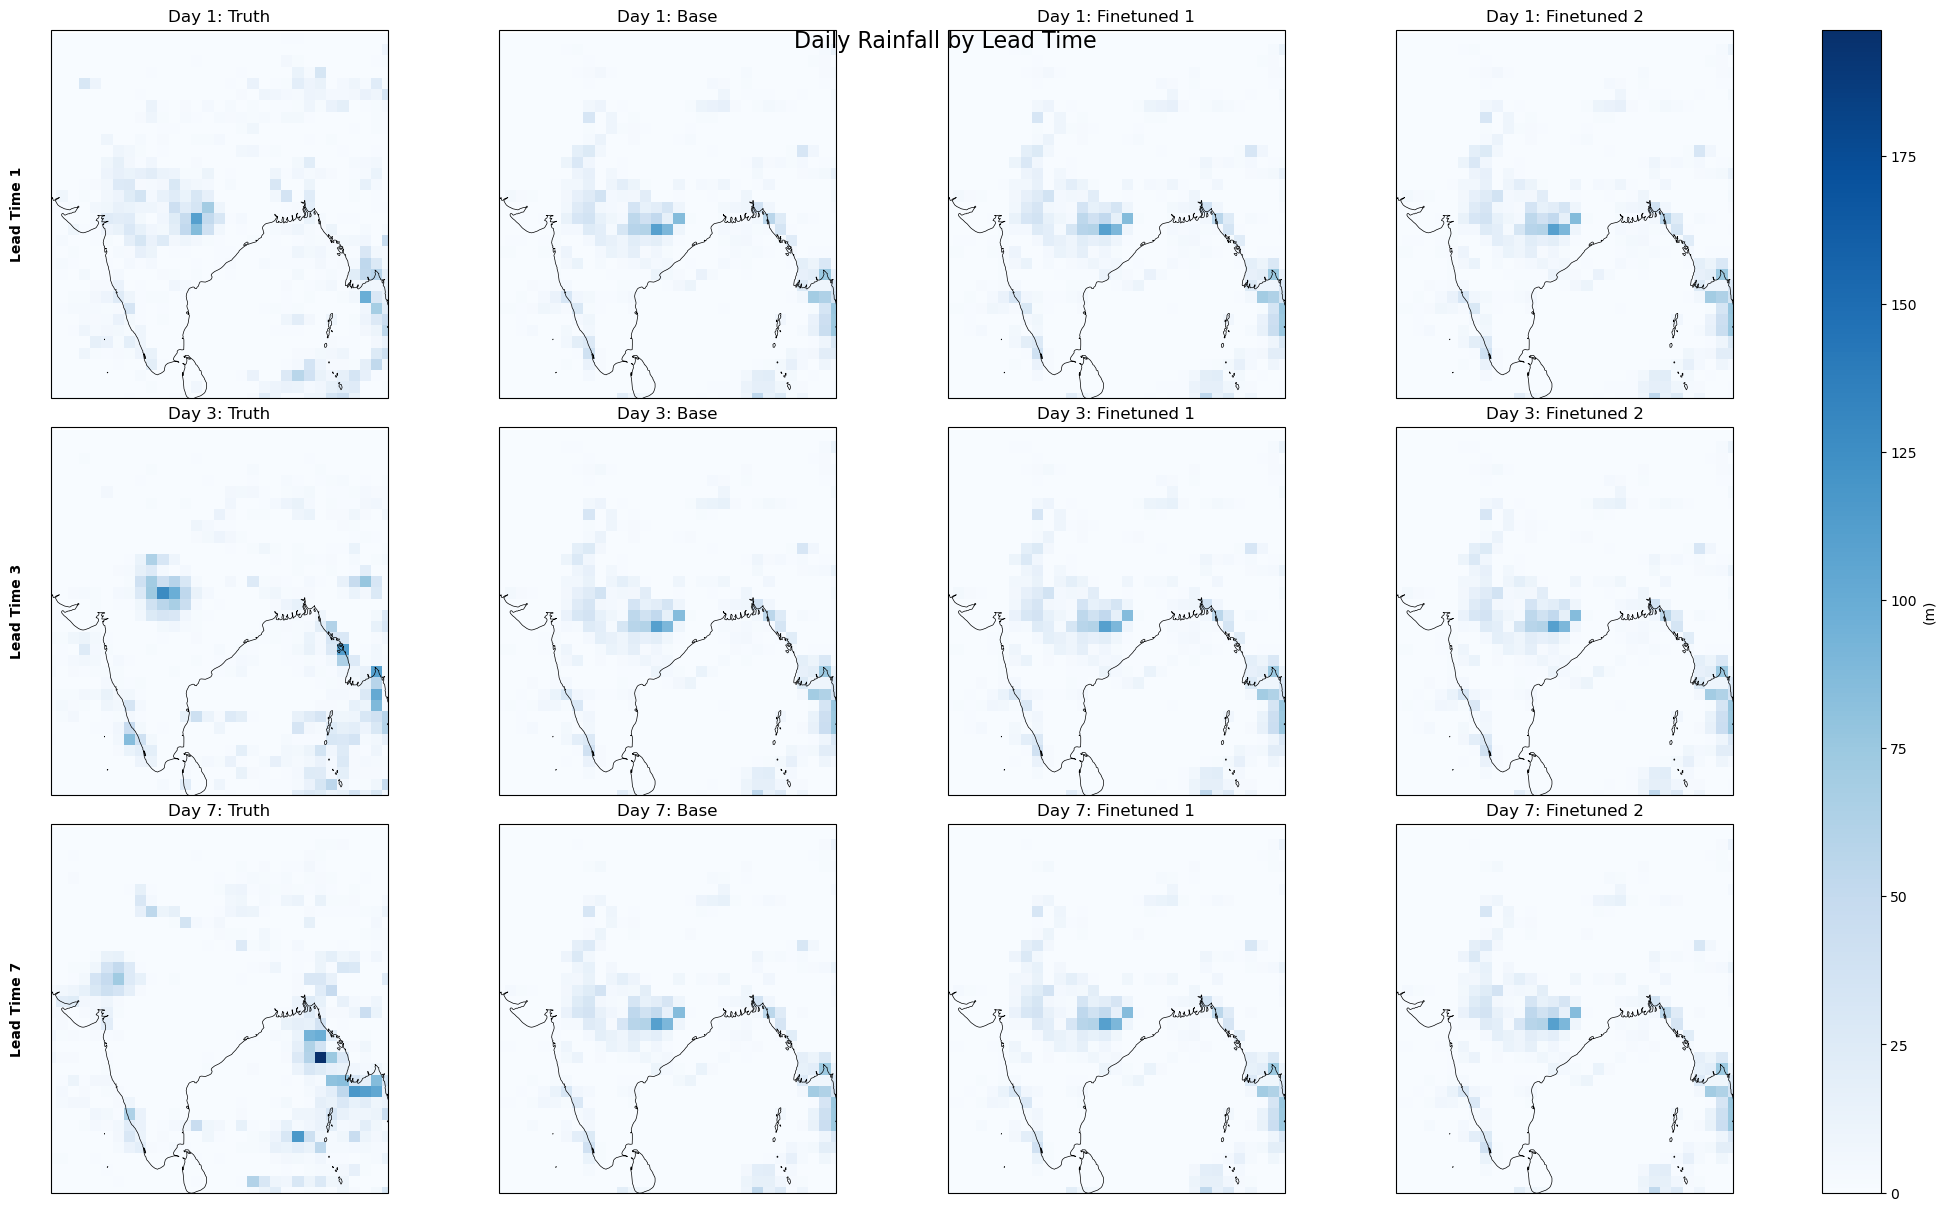

In [23]:
fig, ax = accum_time_and_plot_lead(
    eval_targets, predictions_base, predictions_ft1, predictions_ft2,
    var_name="total_precipitation_6hr",
    lead_times=[1, 3, 7],  # Specify which days you want
    indiaplot=True, 
    india_shape=False, 
    region_shape=None, 
    cmap='Blues', 
    xlabel='°E', 
    ylabel='°N', 
    outline=True, 
    subplot_titles=['Truth', 'Base', 'Finetuned 1', 'Finetuned 2'], 
    units='(m)'
)

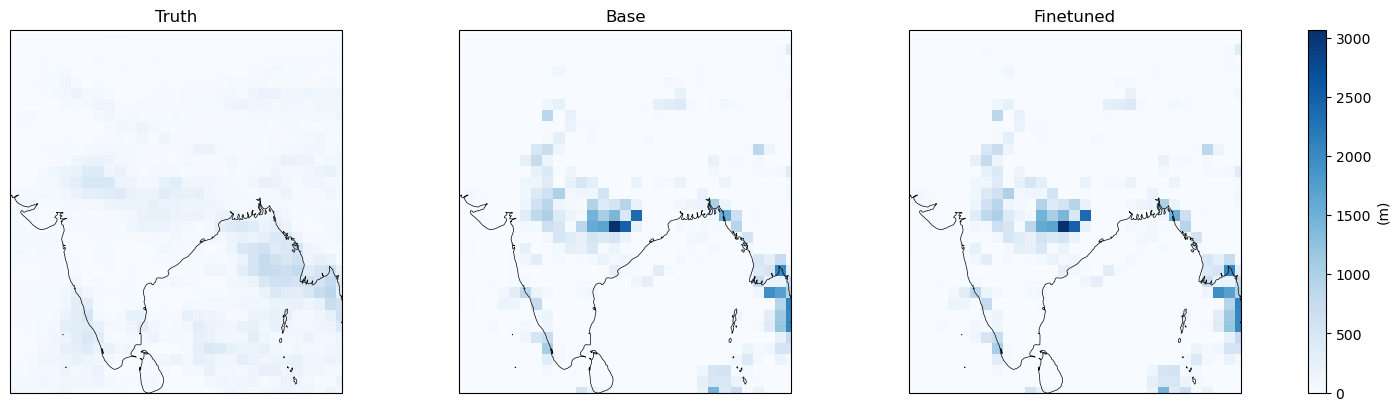

In [24]:
fig, ax = accum_time_and_plot_ds(eval_targets, predictions_base, predictions_ft1,
                              var_name="total_precipitation_6hr",
                              indiaplot=True, india_shape=False, region_shape=None, cmap='Blues', xlabel='°E', ylabel='°N', outline=True, subplot_titles=['Truth', 'Base', 'Finetuned'], units='(m)')

In [25]:
diff_base = (
    eval_targets - predictions_base
).assign_attrs(plot_label="Diff: Eval Targets - Base")

diff_finetuned1 = (
    eval_targets - predictions_ft1
).assign_attrs(plot_label="Diff: Eval Targets - Finetuned 1")

diff_finetuned2 = (
    eval_targets - predictions_ft2
).assign_attrs(plot_label="Diff: Eval Targets - Finetuned 2")

diff_diff = (
    diff_finetuned2 - diff_base
).assign_attrs(plot_label="Diff: Finetuned 1 - Finetuned 2")

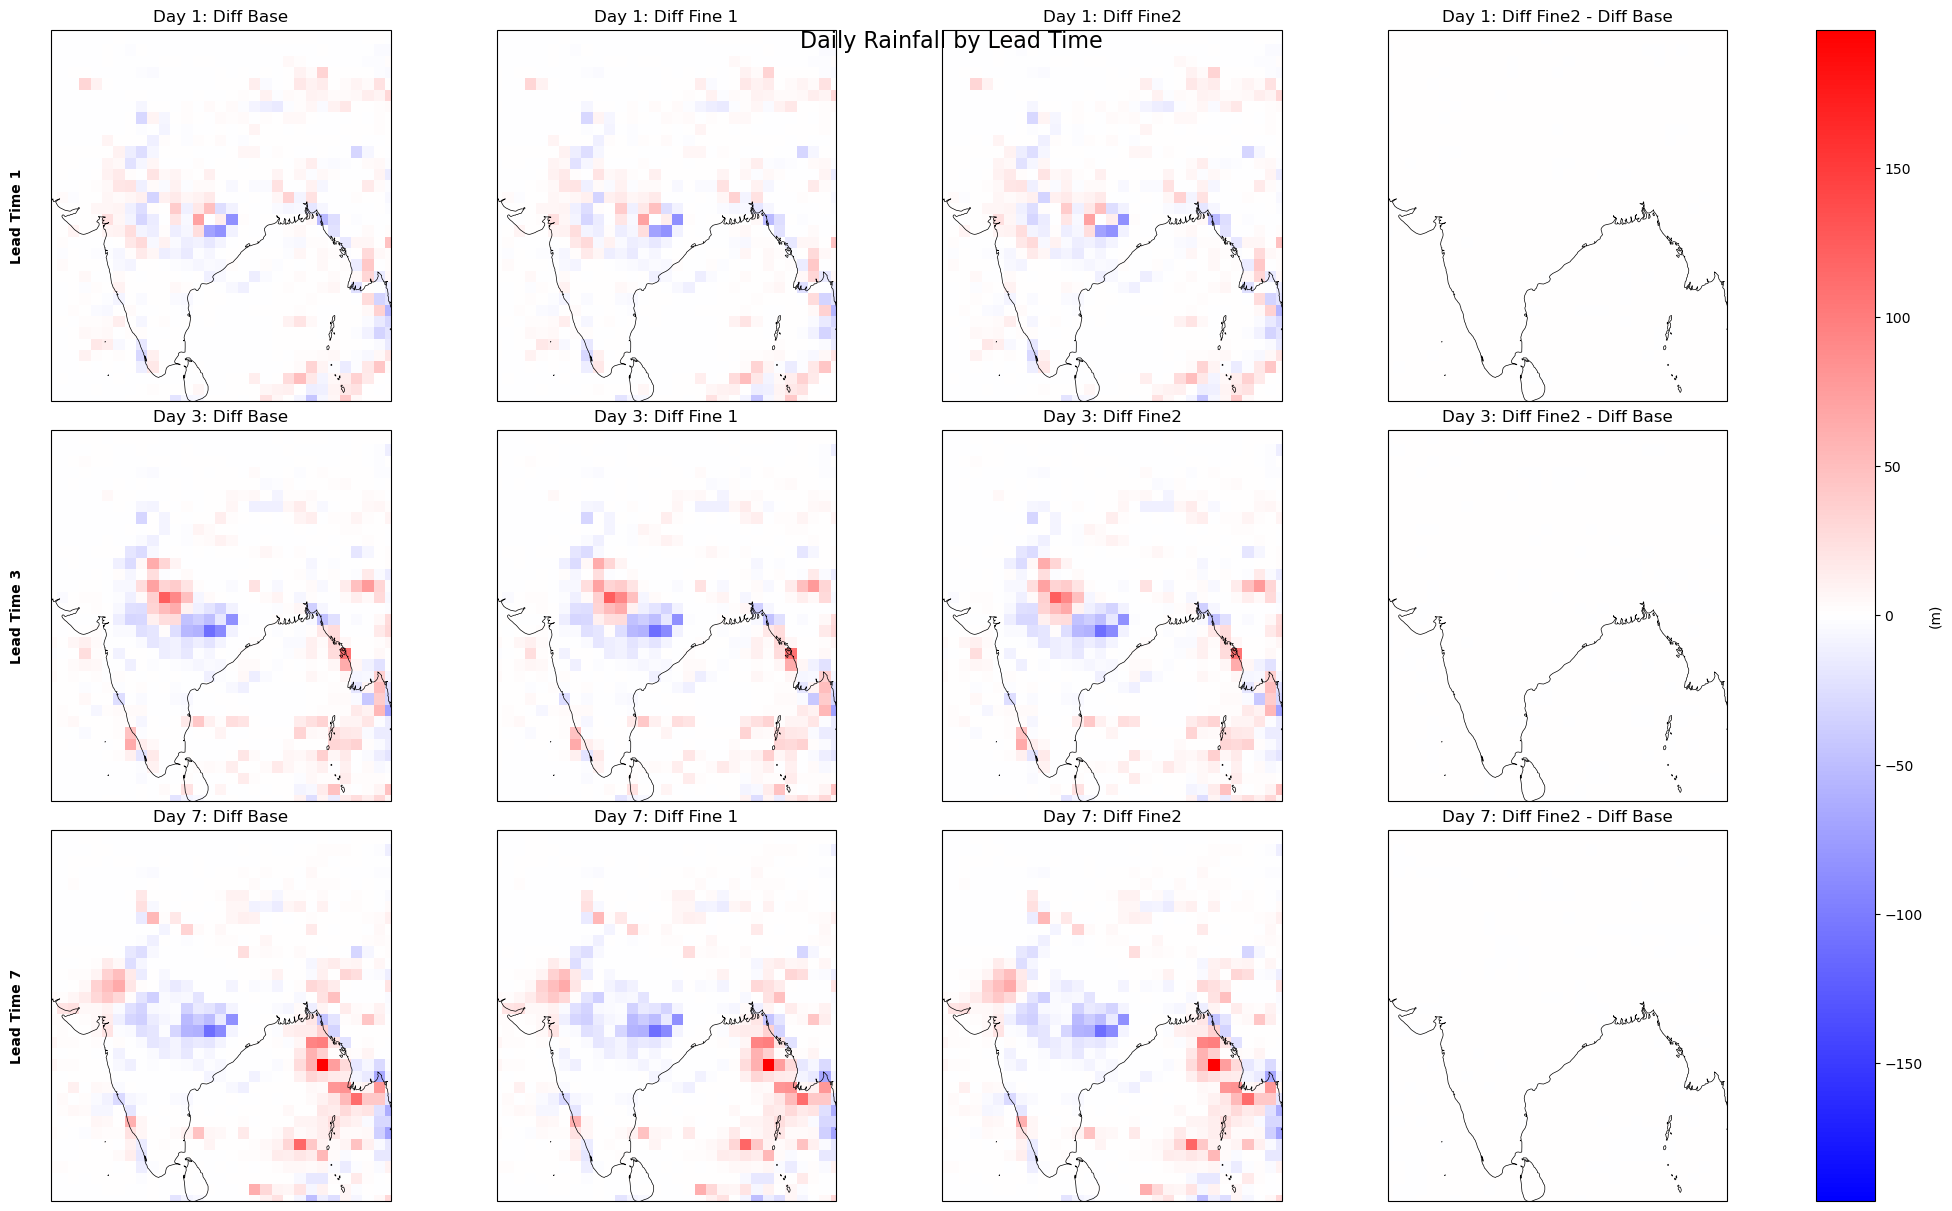

In [26]:
fig, ax = accum_time_and_plot_lead(diff_base, diff_finetuned1, diff_finetuned2, diff_diff,
                              var_name="total_precipitation_6hr",
                              lead_times=[1, 3, 7],
                              indiaplot=True, india_shape=False, region_shape=None, cmap='Blues', xlabel='°E', ylabel='°N', outline=True, subplot_titles=['Diff Base', 'Diff Fine 1', 'Diff Fine2', 'Diff Fine2 - Diff Base'], units='(m)', isdiff=True)

In [27]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def percent_improvement_map(
    forecast: xr.Dataset | xr.DataArray,
    baseline: xr.Dataset | xr.DataArray,
    truth: xr.Dataset | xr.DataArray,
    *,
    var_name: str = "total_precipitation_6hr",
    agg: str = "rmse",                      # "rmse" | "mse" | "mae"
    india_bbox: tuple[float, float, float, float] | None = (6.0, 38.0, 68.0, 98.0),
    improvement_clip: tuple[float, float] = (-100.0, 100.0),
    baseline_eps: float = 1e-12,
    cmap: str = "RdYlGn",
    title: str | None = None,
    overlay_india_political: bool = True,   # <-- NEW
    cartopy_resolution: str = "50m"         # "110m" | "50m" | "10m"
):
    """
    % improvement = 100 * (err_baseline - err_model) / err_baseline
      > 0 : forecast better than baseline (lower error vs truth)
      < 0 : forecast worse
    Returns: (improvement_da, fig, ax)
    """

    def get_da(obj):
        if isinstance(obj, xr.Dataset):
            if var_name not in obj:
                raise KeyError(f"{var_name!r} not in {list(obj.data_vars)}")
            da = obj[var_name]
        else:
            da = obj
        if "batch" in da.dims:
            da = da.squeeze("batch", drop=True)
        ren = {}
        if "latitude" in da.coords: ren["latitude"] = "lat"
        if "longitude" in da.coords: ren["longitude"] = "lon"
        return da.rename(ren) if ren else da

    def normalize_lon0_360(da):
        if "lon" not in da.coords:
            return da
        lon = da["lon"]
        if (lon.min() < 0) or (lon.max() <= 180):
            da = da.assign_coords(lon=((lon + 360) % 360)).sortby("lon")
        return da

    def detect_time_name(da):
        for cand in ("time", "valid_time"):
            if cand in da.dims:
                return cand
        for d in da.dims:
            if np.issubdtype(da[d].dtype, np.datetime64) or np.issubdtype(da[d].dtype, "timedelta64"):
                return d
        raise ValueError("No time-like dimension found.")

    def subset_india(da):
        if india_bbox is None:
            return da
        lat_min, lat_max, lon_min, lon_max = india_bbox
        lat = da["lat"]
        lat_slice = slice(lat_min, lat_max) if lat[0] < lat[-1] else slice(lat_max, lat_min)
        return da.sel(lat=lat_slice, lon=slice(lon_min, lon_max))

    # ---- prep & align ----
    fa, fb, tr = map(get_da, (forecast, baseline, truth))
    fa, fb, tr = map(normalize_lon0_360, (fa, fb, tr))
    tname = detect_time_name(fa)
    fa, fb, tr = xr.align(fa, fb, tr, join="inner")

    fa = subset_india(fa)
    fb = subset_india(fb)
    tr = subset_india(tr)

    # ---- errors (aggregate over time, per grid cell) ----
    agg_l = agg.lower()
    if agg_l == "rmse":
        err_a = ((fa - tr) ** 2).mean(tname, skipna=True) ** 0.5
        err_b = ((fb - tr) ** 2).mean(tname, skipna=True) ** 0.5
    elif agg_l == "mse":
        err_a = ((fa - tr) ** 2).mean(tname, skipna=True)
        err_b = ((fb - tr) ** 2).mean(tname, skipna=True)
    elif agg_l == "mae":
        err_a = (fa - tr).abs().mean(tname, skipna=True)
        err_b = (fb - tr).abs().mean(tname, skipna=True)
    else:
        raise ValueError("agg must be one of {'rmse','mse','mae'}")

    denom = xr.where(np.abs(err_b) < baseline_eps, np.nan, err_b)
    improvement = 100.0 * (err_b - err_a) / denom
    improvement = improvement.rename(f"%Improvement_{agg.upper()}_{var_name}")
    improvement = improvement.assign_attrs(description="Positive = forecast better than baseline (lower error)")

    # ---- plotting (with optional India political overlay) ----
    vmin, vmax = improvement_clip
    if overlay_india_political:
        try:
            import cartopy.crs as ccrs
            import cartopy.feature as cfeature
            from cartopy.io import shapereader as shpreader

            proj = ccrs.PlateCarree()
            fig = plt.figure(figsize=(7.6, 4.6))
            ax = plt.axes(projection=proj)

            # plot data in PlateCarree coords
            im = improvement.plot(
                ax=ax, transform=proj, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True,
                cbar_kwargs={"label": f"% improvement vs baseline ({agg.upper()})"}
            )

            # coastlines & borders
            ax.coastlines(resolution=cartopy_resolution, linewidth=0.6)
            ax.add_feature(cfeature.BORDERS.with_scale(cartopy_resolution), linewidth=0.5)

            # country outline (India)
            shp0 = shpreader.natural_earth(resolution=cartopy_resolution, category="cultural", name="admin_0_countries")
            recs0 = shpreader.Reader(shp0).records()
            inds = [r.geometry for r in recs0 if r.attributes.get("ADM0_A3") == "IND"]
            if inds:
                ax.add_geometries(inds, proj, facecolor="none", edgecolor="black", linewidth=1.0, zorder=3)

            # admin-1 (states) lines for India
            shp1 = shpreader.natural_earth(resolution=cartopy_resolution, category="cultural", name="admin_1_states_provinces_lines")
            recs1 = shpreader.Reader(shp1).records()
            ind_states = [r.geometry for r in recs1 if (r.attributes.get("adm0_a3") == "IND")]
            if ind_states:
                ax.add_geometries(ind_states, proj, facecolor="none", edgecolor="0.4", linewidth=0.4, zorder=3)

            # extent to bbox if given
            if india_bbox is not None:
                lat_min, lat_max, lon_min, lon_max = india_bbox
                ax.set_extent((lon_min, lon_max, lat_min, lat_max), crs=proj)

            gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, x_inline=False, y_inline=False)
            gl.top_labels = gl.right_labels = False

            ax.set_title(title or f"% Improvement map ({agg.upper()} of {var_name})\npositive = better than baseline")

            return improvement, fig, ax

        except Exception as e:
            print(f"[percent_improvement_map] Cartopy overlay failed ({e}). Falling back to plain plot.")

    # fallback: plain image (no political overlay)
    fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
    im = improvement.plot(
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True,
        cbar_kwargs={"label": f"% improvement vs baseline ({agg.upper()})"}
    )
    if india_bbox is not None:
        ax.set_xlim(india_bbox[2], india_bbox[3])
        ax.set_ylim(india_bbox[0], india_bbox[1])
    ax.set_title(title or f"% Improvement map ({agg.upper()} of {var_name})\npositive = better than baseline")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(False)
    return improvement, fig, ax


(<xarray.DataArray '%Improvement_RMSE_total_precipitation_6hr' (lat: 33, lon: 31)> Size: 4kB
 xarray_jax.JaxArrayWrapper(Array([[-1.0136785e-03, -1.2874453e-03, -1.3183621e-03, ...,
         -3.6173897e-05,  6.0538663e-05,  2.1297712e-04],
        [-1.0938885e-02, -3.9545521e-03, -5.4536676e-03, ...,
          1.2667917e-04, -3.3285154e-04,  1.1759598e-03],
        [-2.6945431e-02, -1.7813830e-02, -5.5852560e-03, ...,
          3.7879907e-03,  1.0623529e-04, -8.3652261e-04],
        ...,
        [ 1.9611990e+01,  1.5209141e+01, -1.4033986e-02, ...,
         -2.3799504e-03, -1.5806326e-03, -2.1958111e-03],
        [ 2.3105825e+01,  1.7276564e+01, -5.2864631e-03, ...,
         -2.5929881e-03, -3.6660526e-03,  7.7075441e-03],
        [ 1.9765005e+01,  3.3999561e+01,  1.6764330e+01, ...,
         -9.0115862e-03,  1.4381589e-04, -3.8438700e-03]], dtype=float32))
 Coordinates:
   * lat      (lat) float64 264B 6.0 7.0 8.0 9.0 10.0 ... 35.0 36.0 37.0 38.0
   * lon      (lon) float64 248B 68.0 

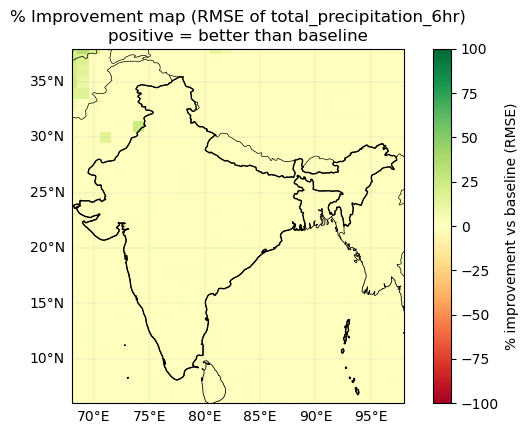

In [28]:
percent_improvement_map(
    forecast=predictions_ft1,
    baseline=predictions_base,
    truth=eval_targets,
    var_name="total_precipitation_6hr",
    agg="rmse",
    india_bbox=(6.0, 38.0, 68.0, 98.0))

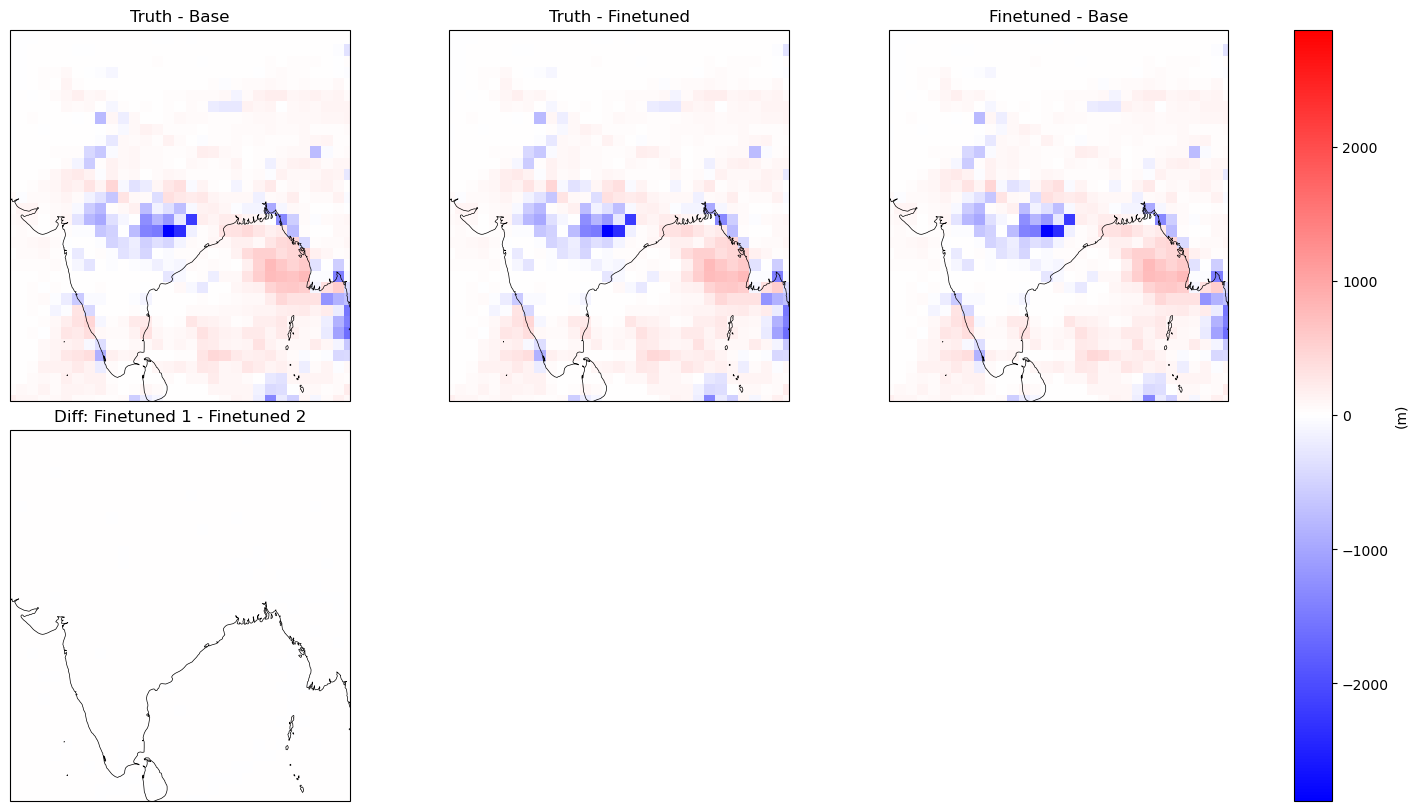

In [29]:
# 2) now plot all four at once
fig, axs = accum_time_and_plot_ds(
    diff_base,
    diff_finetuned2,
    diff_finetuned2,
    diff_diff,
    var_name='total_precipitation_6hr',
    indiaplot=True,
    isdiff=True,
    india_shape=False,
    region_shape=None,
    outline=True,
    subplot_titles=['Truth - Base', 'Truth - Finetuned', 'Finetuned - Base'], units='(m)'
)
# have something that groups areas into bins depending on the reduction that we achieved

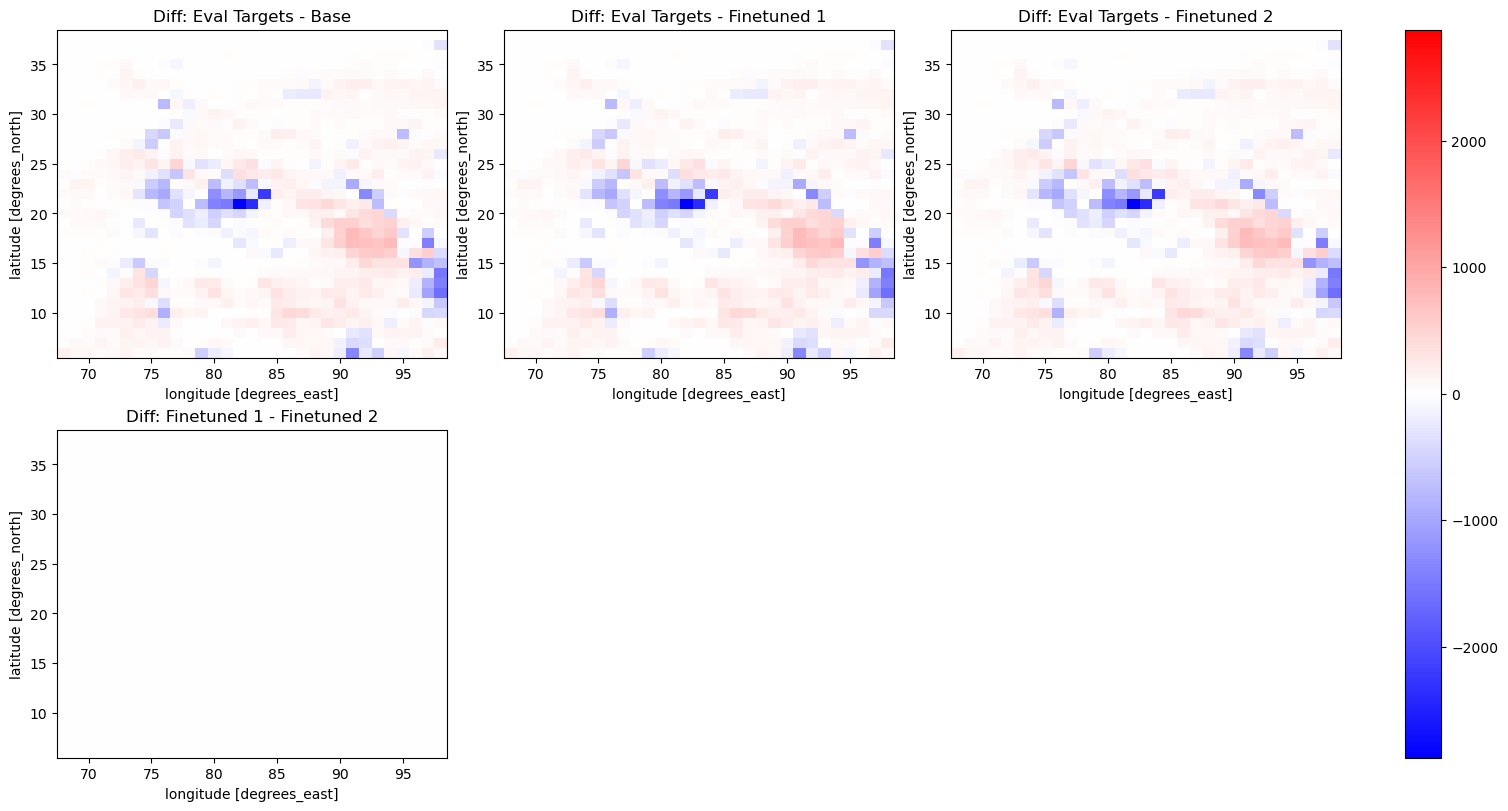

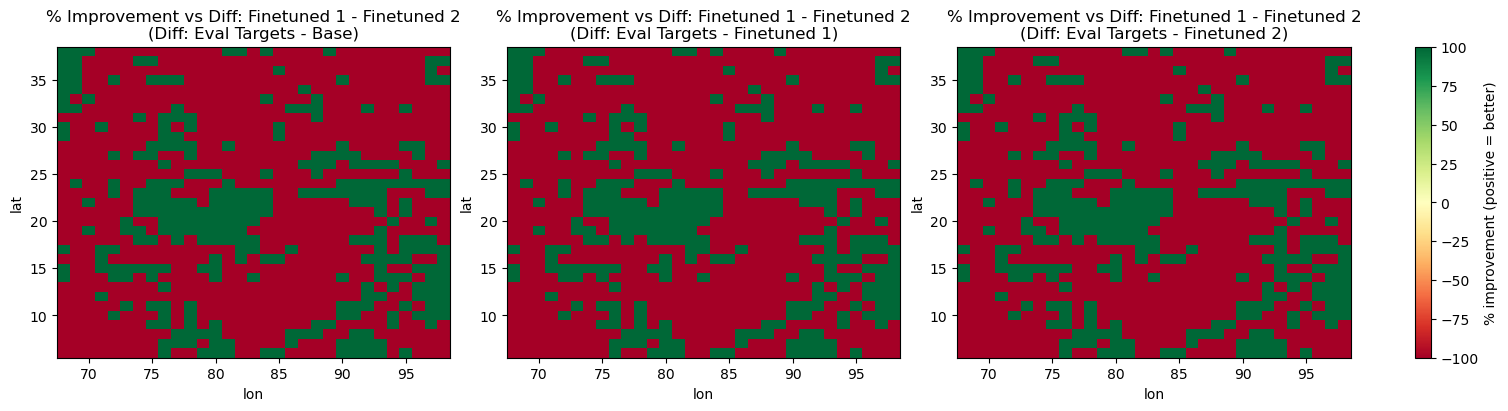

In [30]:
# 2) now plot all four at once
fig = accum_time_and_plot_ds_perc(
    diff_base,
    diff_finetuned1,
    diff_finetuned2,
    diff_diff,
    var_name='total_precipitation_6hr',
    indiaplot=True,
    isdiff=True,
    india_shape=False,
    region_shape=None
)
# have something that groups areas into bins depending on the reduction that we achieved

In [31]:
def plot_rmse_time_series(
    eval_targets,
    *predictions,
    var_name=None,
    ax=None,
    india = True,
    regions = False
):
    """
    Compute and plot RMSE vs time for multiple predictions against eval_targets,
    and plot total precipitation from eval_targets on a secondary y-axis.
    """
    if regions:
        eval_targets = mask_dbase_regions(eval_targets)
    elif india:
        eval_targets = mask_dbase_india_buffer(eval_targets)
    if 'latitude' in eval_targets.coords:
        eval_targets = eval_targets.rename({'latitude': 'lat', 'longitude': 'lon'})
    # extract target DataArray
    if isinstance(eval_targets, xr.Dataset):
        if var_name is None:
            raise ValueError("`var_name` required when eval_targets is a Dataset.")
        target_da = eval_targets[var_name]
    else:
        target_da = eval_targets
    # detect time dim
    if "time" in target_da.dims:
        tdim = "time"
    elif "valid_time" in target_da.dims:
        tdim = "valid_time"
    else:
        tdim = next(d for d in target_da.dims if target_da[d].dtype.kind == "M")
    # compute total precipitation series
    # other_dims = [d for d in target_da.dims if d != tdim]
    total_precip = target_da.sum(dim=('lat', 'lon')) #if other_dims else target_da
    tgt_label = eval_targets.attrs.get("plot_label") or target_da.name or "Eval Targets"
    total_precip.name = tgt_label
    # compute RMSE series for each prediction
    rmse_series = {}
    for pred in predictions:
        pred = mask_dbase_india_buffer(pred)
        if isinstance(pred, xr.Dataset):
            if var_name is None:
                raise ValueError("`var_name` required when predictions are Datasets.")
            pred_da = pred[var_name]
        else:
            pred_da = pred
        # align and compute squared error
        tgt_al, pr_al = xr.align(target_da, pred_da)
        # del pred
        # del pred_da
        se = (pr_al - tgt_al) ** 2
        # collapse non-time dims
        collapse = [d for d in se.dims if d != tdim]
        mse = se.mean(dim=collapse) if collapse else se
        rmse = np.sqrt(mse)
        lbl = pred.attrs.get("plot_label") or pred_da.name or "Prediction"
        rmse.name = lbl
        rmse_series[lbl] = rmse
    # plotting
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    # plot RMSE on primary y-axis
    for lbl, series in rmse_series.items():
        series.plot(ax=ax, label=lbl)
    ax.set_xlabel(tdim)
    ax.set_ylabel('RMSE')
    # secondary axis for total precipitation
    ax2 = ax.twinx()
    total_precip.plot(ax=ax2, label=total_precip.name, color='gray', linestyle='--')
    ax2.set_ylabel('Total Precipitation')
    # combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax.set_title('RMSE Time Series and Total Precipitation')
    return fig, ax, rmse_series

In [32]:
# 2. Prepare inputs, targets, and forcings for a 7-day rollout
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    eval_sim_data, target_lead_times=target_lead_times_slice, **dataclasses.asdict(task_config))
eval_sim_data

<xarray.Dataset> Size: 2GB
Dimensions:                  (batch: 1, time: 30, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 240B 2014-08-04T18:...
  * time                     (time) timedelta64[ns] 240B 4 days 18:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 8MB 0.4251 ... -...
    10m_v_component_of_wind  (batch, time, lat, lon) float32 8MB -0.07279 ......
    2m_temperature           (batch, time, lat, lon) float32 8MB 212.3 ... 273.7
    geopotential             (batch, time, level, lat, lon) float32 289MB 4.0...
    geopotential_at_surface  (batch, lat, lon) float32 261kB 2.736e+04 ... 0....
    land_sea_mask            (batch, lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 289MB 3.6...
    temperature              (batch, time, level, lat, lon) float32 289MB 241...
    total_precipitation_6hr  (batch, time, lat, lon) float32 8MB 0.0 0.0 ... 0.0
    u_component_of_wind      (batch, time, level, lat, lon) float32 289MB -0....
    v_component_of_wind      (batch, time, level, lat, lon) float32 289MB 0.0...
    vertical_velocity        (batch, time, level, lat, lon) float32 289MB 0.0...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-06T09:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [33]:
eval_targets_orig = eval_targets.copy(deep=True)

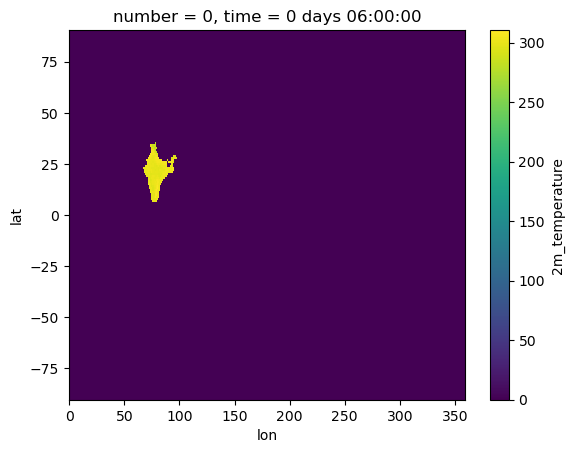

In [34]:
eval_targets = mask_dbase_india_buffer(eval_targets)
eval_targets['2m_temperature'].isel(time=0).plot()

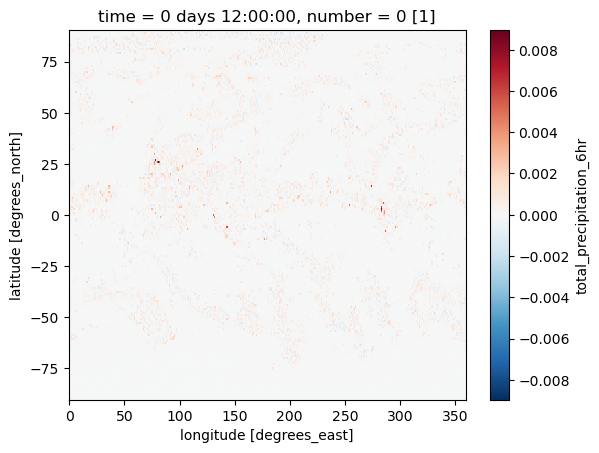

In [35]:
(predictions_base['total_precipitation_6hr'] - predictions_ft1['total_precipitation_6hr']).isel(time=1).plot()

((<Figure size 1500x800 with 7 Axes>,
  array([<Axes: title={'center': 'Diff: Eval Targets - Base'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
         <Axes: title={'center': 'Diff: Eval Targets - Finetuned 1'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
         <Axes: title={'center': 'Diff: Eval Targets - Finetuned 2'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
         <Axes: title={'center': 'Diff: Finetuned 1 - Finetuned 2'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
         <Axes: >, <Axes: >], dtype=object),
  <Figure size 1500x400 with 4 Axes>,
  array([<Axes: title={'center': '% Improvement vs Diff: Finetuned 1 - Finetuned 2\n(Diff: Eval Targets - Base)'}, xlabel='lon', ylabel='lat'>,
         <Axes: title={'center': '% Improvement vs Diff: Finetuned 1 - Finetuned 2\n(Diff: Eval Targets - Finetuned 1)'}, xlabel='lon', ylabel='lat'>,
         <Axes: title={'cent

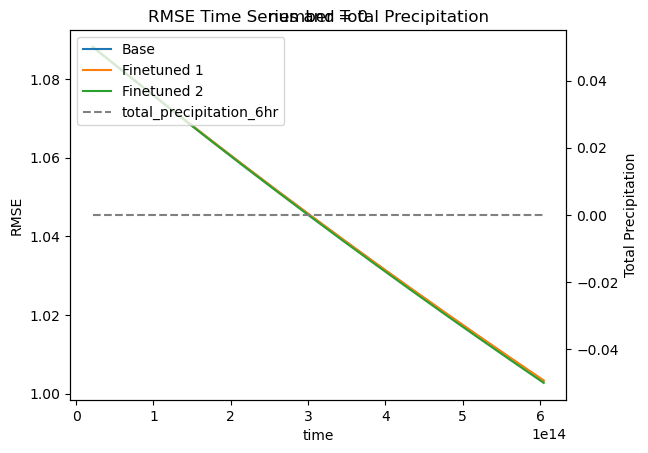

In [38]:
time_slice = slice(None, None)
fix, ax, rmse_series = plot_rmse_time_series(eval_targets.isel(time=time_slice), predictions_base.isel(time=time_slice), predictions_ft1.isel(time=time_slice), predictions_ft2.isel(time=time_slice), var_name='total_precipitation_6hr')
fig, ax

In [37]:
rmse_series

{'Base': <xarray.DataArray 'Base' (time: 28)> Size: 112B
 xarray_jax.JaxArrayWrapper(Array([1.0881356, 1.0847293, 1.0813574, 1.0779796, 1.0746233, 1.071279 ,
        1.067963 , 1.0646504, 1.0613914, 1.0581281, 1.0549122, 1.0517002,
        1.0485383, 1.0453638, 1.0422366, 1.0391026, 1.0360208, 1.0329299,
        1.0298855, 1.0268358, 1.02384  , 1.0208304, 1.017865 , 1.0148954,
        1.0119743, 1.0090423, 1.006154 , 1.0032556], dtype=float32))
 Coordinates:
   * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
     number   int64 8B 0,
 'Finetuned 1': <xarray.DataArray 'Finetuned 1' (time: 28)> Size: 112B
 xarray_jax.JaxArrayWrapper(Array([1.0881371, 1.0847279, 1.0813564, 1.0779783, 1.0746218, 1.0712761,
        1.0679624, 1.0646497, 1.061391 , 1.0581243, 1.054909 , 1.051698 ,
        1.0485362, 1.0453651, 1.0422387, 1.0391093, 1.0360261, 1.032939 ,
        1.0298996, 1.026854 , 1.0238627, 1.0208555, 1.0178926, 1.014928 ,
        1.0120116, 1.0090804, 1.0061977